In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, RepeatedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

df = pd.read_csv('Iris.csv')

X = df.drop(columns=['Id', 'Species'], errors='ignore')
y = df['Species']
classes = y.unique()

In [6]:
for i in range(5):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42 + i)
    
    rf = RandomForestClassifier(n_estimators=100, random_state=42 + i)
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"--- Iteration {i + 1} ---")
    print(f"Accuracy: {acc:.4f} | F1 Score: {f1:.4f} | ROC-AUC: {roc_auc:.4f}")
    print("Confusion Matrix:\n", cm)
    print()

--- Iteration 1 ---
Accuracy: 1.0000 | F1 Score: 1.0000 | ROC-AUC: 1.0000
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

--- Iteration 2 ---
Accuracy: 0.9556 | F1 Score: 0.9556 | ROC-AUC: 0.9940
Confusion Matrix:
 [[15  0  0]
 [ 0 16  1]
 [ 0  1 12]]

--- Iteration 3 ---
Accuracy: 0.9778 | F1 Score: 0.9778 | ROC-AUC: 0.9969
Confusion Matrix:
 [[17  0  0]
 [ 0 13  0]
 [ 0  1 14]]

--- Iteration 4 ---
Accuracy: 0.9556 | F1 Score: 0.9556 | ROC-AUC: 1.0000
Confusion Matrix:
 [[17  0  0]
 [ 0 13  0]
 [ 0  2 13]]

--- Iteration 5 ---
Accuracy: 0.8889 | F1 Score: 0.8890 | ROC-AUC: 0.9880
Confusion Matrix:
 [[17  0  0]
 [ 0 11  2]
 [ 0  3 12]]



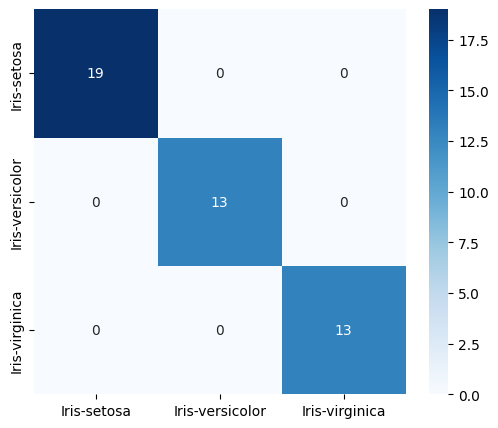

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.show()

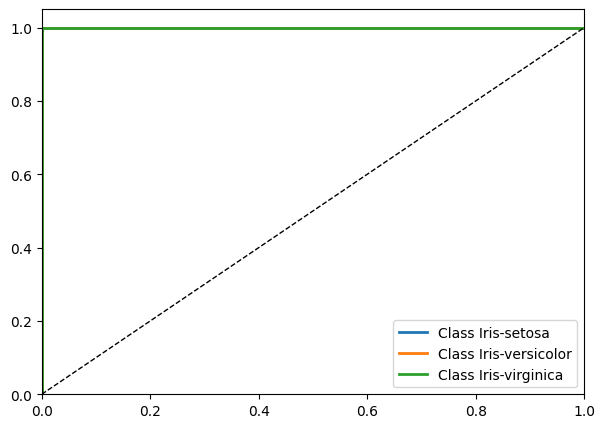

In [8]:
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(7, 5))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'Class {classes[i]}')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower right")
plt.show()

In [9]:
scoring_metrics = ['accuracy', 'f1_weighted', 'roc_auc_ovr']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

rf_cv = RandomForestClassifier(n_estimators=100, random_state=42)

kf_results = cross_validate(rf_cv, X, y, cv=kf, scoring=scoring_metrics)
skf_results = cross_validate(rf_cv, X, y, cv=skf, scoring=scoring_metrics)
rkf_results = cross_validate(rf_cv, X, y, cv=rkf, scoring=scoring_metrics)

print("K-Fold Mean Results:")
print("Accuracy:", kf_results['test_accuracy'].mean())
print("F1 Score:", kf_results['test_f1_weighted'].mean())
print("ROC-AUC :", kf_results['test_roc_auc_ovr'].mean())
print()

print("Stratified K-Fold Mean Results:")
print("Accuracy:", skf_results['test_accuracy'].mean())
print("F1 Score:", skf_results['test_f1_weighted'].mean())
print("ROC-AUC :", skf_results['test_roc_auc_ovr'].mean())
print()

print("Repeated K-Fold Mean Results:")
print("Accuracy:", rkf_results['test_accuracy'].mean())
print("F1 Score:", rkf_results['test_f1_weighted'].mean())
print("ROC-AUC :", rkf_results['test_roc_auc_ovr'].mean())

K-Fold Mean Results:
Accuracy: 0.9600000000000002
F1 Score: 0.95990231990232
ROC-AUC : 0.9949189556382538

Stratified K-Fold Mean Results:
Accuracy: 0.9466666666666667
F1 Score: 0.9464317359054201
ROC-AUC : 0.9943333333333333

Repeated K-Fold Mean Results:
Accuracy: 0.9555555555555556
F1 Score: 0.9554594003451954
ROC-AUC : 0.9938187306380633
